In [1]:
import os
from typing import Annotated, Literal

import httpx
from langchain.tools import InjectedToolArg, tool
from markdownify import markdownify
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


def fetch_webpage_content(url: str, timeout: float = 10.0) -> str:
    """Fetch webpage and convert HTML to markdown."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    try:
        response = httpx.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
        return markdownify(response.text)
    except Exception as e:
        return f"Error fetching {url}: {e!s}"


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[
        Literal["general", "news", "finance"], InjectedToolArg
    ] = "general",
) -> str:
    """Search the web for information on a given query.

    Uses Tavily to discover relevant URLs, then fetches and returns full webpage content as markdown.

    Args:
        query: Search query to execute
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Formatted search results with full webpage content
    """
    search_results = tavily_client.search(
        query,
        max_results=max_results,
        topic=topic,
    )
    result_texts = []
    for result in search_results.get("results", []):
        url = result["url"]
        title = result["title"]
        content = fetch_webpage_content(url)
        result_texts.append(f"## {title}\n**URL:** {url}\n\n{content}\n---")

    return f"Found {len(result_texts)} result(s) for '{query}':\n\n" + "\n".join(
        result_texts
    )

In [2]:
RESEARCH_WORKFLOW_INSTRUCTIONS = """# Research Workflow

Follow this workflow for all research requests:

1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks
2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`
3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for research, never conduct research yourself
4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number across all findings)
5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines below)
6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and structure

## Research Planning Guidelines
- Batch similar research tasks into a single TODO to minimize overhead
- For simple fact-finding questions, use 1 sub-agent
- For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents
- Each sub-agent should research one specific aspect and return findings

## Report Writing Guidelines

When writing the final report to `/final_report.md`, follow these structure patterns:

**For comparisons:**
1. Introduction
2. Overview of topic A
3. Overview of topic B
4. Detailed comparison
5. Conclusion

**For lists/rankings:**
Simply list items with details - no introduction needed:
1. Item 1 with explanation
2. Item 2 with explanation
3. Item 3 with explanation

**For summaries/overviews:**
1. Overview of topic
2. Key concept 1
3. Key concept 2
4. Key concept 3
5. Conclusion

**General guidelines:**
- Use clear section headings (## for sections, ### for subsections)
- Write in paragraph form by default - be text-heavy, not just bullet points
- Do NOT use self-referential language ("I found...", "I researched...")
- Write as a professional report without meta-commentary
- Each section should be comprehensive and detailed
- Use bullet points only when listing is more appropriate than prose

**Citation format:**
- Cite sources inline using [1], [2], [3] format
- Assign each unique URL a single citation number across ALL sub-agent findings
- End report with ### Sources section listing each numbered source
- Number sources sequentially without gaps (1,2,3,4...)
- Format: [1] Source Title: URL (each on separate line for proper list rendering)
- Example:

 Some important finding [1]. Another key insight [2].

 ### Sources
 [1] AI Research Paper: https://example.com/paper
 [2] Industry Analysis: https://example.com/analysis
"""

In [3]:
RESEARCHER_INSTRUCTIONS = """You are a research assistant conducting research on the user's input topic. For context, today's date is {date}.

Your job is to use tools to gather information about the user's input topic.
You can use the tavily_search tool to find resources that can help answer the research question.
You can call it in series or in parallel, your research is conducted in a tool-calling loop.

You have access to the tavily_search tool for conducting web searches.

Think like a human researcher with limited time. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Start with broader searches** - Use broad, comprehensive queries first
3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?
4. **Execute narrower searches as you gather information** - Fill in the gaps
5. **Stop when you can answer confidently** - Don't keep searching for perfection

**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 2-3 search tool calls maximum
- **Complex queries**: Use up to 5 search tool calls maximum
- **Always stop**: After 5 search tool calls if you cannot find the right sources

**Stop Immediately When**:
- You can answer the user's question comprehensively
- You have 3+ relevant examples/sources for the question
- Your last 2 searches returned similar information

After each search, assess results before continuing: What key information did I find? What's missing? Do I have enough to answer? Should I search more or provide my answer?

When providing your findings back to the orchestrator:

1. **Structure your response**: Organize findings with clear headings and detailed explanations
2. **Cite sources inline**: Use [1], [2], [3] format when referencing information from your searches
3. **Include Sources section**: End with ### Sources listing each numbered source with title and URL

Example:
## Key Findings

Context engineering is a critical technique for AI agents [1]. Studies show that proper context management can improve performance by 40% [2].

### Sources
[1] Context Engineering Guide: https://example.com/context-guide
[2] AI Performance Study: https://example.com/study

The orchestrator will consolidate citations from all sub-agents into the final report.
"""

In [4]:
SUBAGENT_DELEGATION_INSTRUCTIONS = """# Sub-Agent Research Coordination

Your role is to coordinate research by delegating tasks from your TODO list to specialized research sub-agents.

## Delegation Strategy

**DEFAULT: Start with 1 sub-agent** for most queries:
- "What is quantum computing?" -> 1 sub-agent (general overview)
- "List the top 10 coffee shops in San Francisco" -> 1 sub-agent
- "Summarize the history of the internet" -> 1 sub-agent
- "Research context engineering for AI agents" -> 1 sub-agent (covers all aspects)

**ONLY parallelize when the query EXPLICITLY requires comparison or has clearly independent aspects:**

**Explicit comparisons** -> 1 sub-agent per element:
- "Compare OpenAI vs Anthropic vs DeepMind AI safety approaches" -> 3 parallel sub-agents
- "Compare Python vs JavaScript for web development" -> 2 parallel sub-agents

**Clearly separated aspects** -> 1 sub-agent per aspect (use sparingly):
- "Research renewable energy adoption in Europe, Asia, and North America" -> 3 parallel sub-agents (geographic separation)
- Only use this pattern when aspects cannot be covered efficiently by a single comprehensive search

## Key Principles
- **Bias towards single sub-agent**: One comprehensive research task is more token-efficient than multiple narrow ones
- **Avoid premature decomposition**: Don't break "research X" into "research X overview", "research X techniques", "research X applications" - just use 1 sub-agent for all of X
- **Parallelize only for clear comparisons**: Use multiple sub-agents when comparing distinct entities or geographically separated data

## Parallel Execution Limits
- Use at most {max_concurrent_research_units} parallel sub-agents per iteration
- Make multiple task() calls in a single response to enable parallel execution
- Each sub-agent returns findings independently

## Research Limits
- Stop after {max_researcher_iterations} delegation rounds if you haven't found adequate sources
- Stop when you have sufficient information to answer comprehensively
- Bias towards focused research over exhaustive exploration"""

In [5]:
from datetime import datetime
from utils.langchain_model import get_singleton_client

from deepagents import create_deep_agent

max_concurrent_research_units = 3
max_researcher_iterations = 3

current_date = datetime.now().strftime("%Y-%m-%d")

INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent. Give one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search],
}

model = get_singleton_client(llm_provider="bailing")

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
)

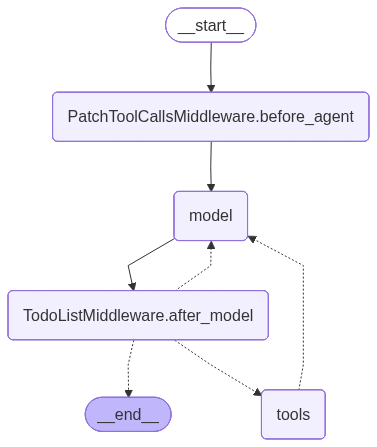

In [6]:
agent

In [7]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="What are the main differences between RAG and fine-tuning for LLM applications?")]

for chunk in agent.stream({"messages": messages}):
    print(chunk)

{'PatchToolCallsMiddleware.before_agent': None}
{'model': {'messages': [AIMessage(content="I'll research the main differences between RAG (Retrieval-Augmented Generation) and fine-tuning for LLM applications. Let me delegate this to a research sub-agent to get comprehensive information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 7365, 'total_tokens': 7524, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': None, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'Ling-2.6-1T', 'system_fingerprint': None, 'id': '0a640e6317819216843461546793', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee2cf-1941-7f22-802a-66130a363a1d-0', tool_calls=[{'name': 'task', 'args': {'description': 'Research and compare RAG (Retrieval-Augmented Generation) vs fine-